# RETINOPATHY
This project segments the optical disk of fundus images using the UNet architecture (based on `pytorch` and `segmentation_models_pytorch`).

## Dataset
This project uses the dataset from the [IDRiD Diabetic Retinopathy - Segmentation and Grading Challenge](https://idrid.grand-challenge.org/Data/). The dataset consists of 516 fundus images, which were captured and graded by a clinician. In the segmentation dataset, there are 54 training images and 27 testing images along with corresponding ground truth masks of the segmented optical disk. 

## Set-up
Import all necessary libraries

In [121]:
# import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os import listdir, chdir
from os.path import join
%matplotlib inline
import seaborn as sns

In [87]:
# import image processing and pytoch
from PIL import Image
from torchvision import tv_tensors
from torchvision.transforms import v2

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

### Helper functions

In [88]:
def df_of_filepaths(images_path, masks_path):
    """
    Create dataframe of paths of images and their corresponding mask based on folders images_path and masks_path
    """

    images = [join(images_path, f).replace("\\","/") for f in listdir(images_path)]
    masks = [join(masks_path, f).replace("\\","/") for f in listdir(masks_path)]
    df = pd.DataFrame({"images": images, "masks": masks})

    return df

In [159]:
def plot_image_and_mask(image, mask, pred=None, title=None):
    if pred is None:
        fig, ax = plt.subplots(1,2, layout="constrained")
    else:
        fig, ax = plt.subplots(1,3, layout="constrained")
        ax[2].set_title("prediction")
        ax[2].imshow(np.asarray(pred), cmap="grey")
    ax[0].set_title("image")
    ax[0].imshow(np.asarray(image))
    ax[1].set_title("mask")
    ax[1].imshow(np.asarray(mask), cmap="grey")

    if title is not None:
        plt.tight_layout()
        plt.suptitle(title)
        fig.subplots_adjust(top=0.9)

    plt.show()


def plot_tensor_image_and_mask(tensor_image, tensor_mask, tensor_pred=None, title=None):

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # unprocess image
    image = tensor_image.numpy().transpose((1, 2, 0))
    image = std * image + mean # Undo preprocessing
    image = np.clip(image, 0, 1) # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    
    # unprocess mask 
    mask = tensor_mask.numpy().transpose((1, 2, 0))
    #mask = std * mask + mean # Undo preprocessing
    mask = np.clip(mask, 0, 1)
    #image = np.clip(image, 0, 1) # Image needs to be clipped between 0 and 1 or it looks like noise when displayed

    if tensor_pred is None:
        plot_image_and_mask(image, mask, title=title)
    else:
        # unprocess pred
        pred = tensor_pred.numpy().transpose((1, 2, 0))
        pred = np.clip(pred, 0, 1)

        plot_image_and_mask(image, mask, pred, title=title)



## Configuration
Paths to the training and testing images and masks - put into a dataframe for easy processing.

In [90]:
train_images_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\1. Original Images\a. Training Set"
test_images_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\1. Original Images\b. Testing Set"
train_masks_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\2. All Segmentation Groundtruths\a. Training Set\5. Optic Disc"
test_masks_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\2. All Segmentation Groundtruths\b. Testing Set\5. Optic Disc"

# create dataframe of paths to files of train and test set
train_df = df_of_filepaths(train_images_path, train_masks_path)
test_df = df_of_filepaths(test_images_path, test_masks_path)

test_df.head()

,images,masks
0,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
1,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
2,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
3,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
4,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...


## Import and Explore Data

All images are named as "IDRiD_xx.jpg" and its corresponding mask is named as "IDRiD_xx_OD.tif" where xx is the id, from 01-81 (54 images are in the training set).

An image and its mask can be brought in and looked based on selecting a random id which exists in the training set. 

In [91]:
idx = 10

image_path = train_df.at[idx, "images"]
mask_path = train_df.at[idx, "masks"]

image = Image.open(image_path)
mask = Image.open(mask_path)

print(f"The shape of the image is {np.asarray(image).shape}.")
print(f"The shape of the mask is {np.asarray(mask).shape}.")

The shape of the image is (2848, 4288, 3).
The shape of the mask is (2848, 4288).


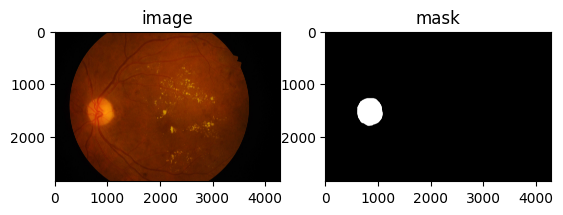

In [92]:
# plot image and its mask
plot_image_and_mask(image, mask)


Each training image is 2848 x 4288 x 3 channels (RGB), while its mask is 2848 x 4288. 

## Preprocessing
The data is preprocessed, and prepared for using as input and test data.

### Augmentation
Augmentions such as random horizontal flips and random rotations are applied to the (training) images and masks. All images and masks are resized, converted to tensors, and normalized. 

These augmentations are first explored on one image-mask set, and then applied to the entire training and testing set via a custom class. 

In [93]:
IMG_SIZE = 224

train_transform = v2.Compose([
    v2.Resize(size=(IMG_SIZE, IMG_SIZE), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(contrast=0.2, brightness=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.Resize(size=(IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

1
0


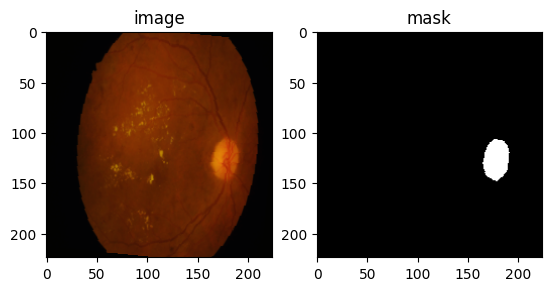

In [94]:
# transform an image and its mask to see the effects of the transforms
image_transform, mask_transform = train_transform(tv_tensors.Image(image), tv_tensors.Mask(mask))
print(torch.max(mask_transform).item())
print(torch.min(mask_transform).item())

# plot transformed image and its mask
plot_tensor_image_and_mask(image_transform, mask_transform)

In [95]:
class SegmentationDataset(Dataset):

    def __init__(self, df, transforms):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # get path to image and mask
        image_path = self.df.at[idx, "images"]
        mask_path = self.df.at[idx, "masks"]

        # open image and path in right mode
        image = Image.open(image_path) # h, w, c
        if image.mode != "RGB":
            image = image.convert("RGB")
        
        mask = Image.open(mask_path) # h, w
        if mask.mode != "L":
            mask = mask.convert("L")
            mask = mask.point(lambda x: 0 if x == 0 else 1)

        # apply transforms
        if self.transforms:
            image_transform, mask_transform =  self.transforms(tv_tensors.Image(image), tv_tensors.Mask(mask))

        return image_transform, mask_transform

In [96]:
# create training and testing set with transformations
trainset = SegmentationDataset(train_df, train_transform)
testset = SegmentationDataset(test_df, test_transform)

print(f"The training set has {len(trainset)} observations.")
print(f"The test set has {len(testset)} observations.")

The training set has 54 observations.
The test set has 27 observations.


1 0


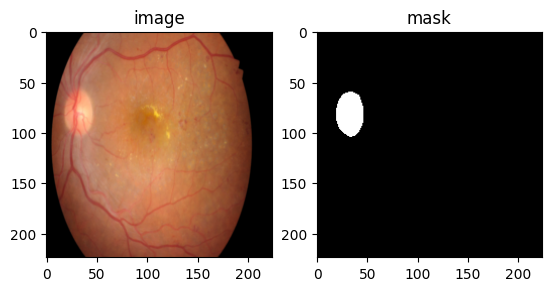

In [97]:
idx = 10
imageX, maskX = testset[idx]
print(torch.max(maskX).item(), torch.min(maskX).item())
plot_tensor_image_and_mask(imageX, maskX)

### Load into batches
The datasets are loaded into batches for efficient computation. A batch size of 16 is used. 

In [98]:
BATCH_SIZE = 16

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE)

print(f"There are {len(trainloader)} batches in the trainloader.")
print(f"There are {len(testloader)} batches in the testloader.")

There are 4 batches in the trainloader.
There are 2 batches in the testloader.


In [99]:
# verify correct size
for imageX, maskX in trainloader:
    break

print(f"One batch image shape: {imageX.shape}")
print(f"One batch mask shape: {maskX.shape}")

One batch image shape: torch.Size([16, 3, 224, 224])
One batch mask shape: torch.Size([16, 1, 224, 224])


## Create Segmentation Model
Create a segmentation model based on the pre-trained UNet architecture (which has been shown to be appropriate for medical images) using and DiceLoss. Custom classes and training and evaluation functions are created. 

In [100]:
# configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {DEVICE}.")


Device is cpu.


In [101]:
# define custom segmentation model class
class SegmentationModel(nn.Module):
    def __init__(self, encoder, weights):
        super(SegmentationModel, self).__init__()

        self.arc = smp.Unet(
            encoder_name=encoder, 
            encoder_weights=weights, 
            in_channels=3, 
            classes=1, 
            activation=None
        )

    def forward(self, images, masks=None):

        logits = self.arc(images)

        if masks != None:
            dice_loss = DiceLoss(mode="binary")(logits, masks)
            bce_loss = nn.BCEWithLogitsLoss()(logits, masks.float())
            return logits, dice_loss, bce_loss
        
        return logits

In [102]:
# define training and validation function for the model
def train_seg_model(data_loader, model, optimizer):

    model.train()
    total_loss = 0.0

    for images, masks in tqdm(data_loader):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()                               # set gradients to 0
        logits, dice_loss, bce_loss = model(images, masks)  # forward pass
        loss = dice_loss + bce_loss
        loss.backward()                                     # backward pass
        optimizer.step()                                    # update weights and biases

        total_loss += loss.item()
    
    return total_loss / len(data_loader)

def test_seg_model(data_loader, model):

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(data_loader):
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            logits, dice_loss, bce_loss = model(images, masks) 
            loss = dice_loss + bce_loss

            total_loss += loss.item()
    
    return total_loss / len(data_loader)

### BASELINE MODEL
Initially, a baseline model will be created considering encoder `"timm-efficientnet-b0"` over 5 epochs, with a learning rate of 0.001.

In [ ]:
model = SegmentationModel(encoder="timm-efficientnet-b0", weights="imagenet")
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_valid_loss = np.inf
corresponding_train_loss = None

# TRAINING LOOP
epochs = 5
for i in range(epochs):
    train_loss = train_seg_model(data_loader=trainloader, model=model, optimizer=optimizer)
    valid_loss = test_seg_model(data_loader=testloader, model=model)

    if abs(valid_loss) < abs(best_valid_loss):
        best_valid_loss = valid_loss
        corresponding_train_loss = train_loss

        torch.save(model.state_dict(), "best_baseline_model.pt")
        print("saved model")

    print(f"    Epoch {i+1}/{epochs}: train_loss {train_loss:.4f} // valid_loss {valid_loss:.4f}")

100%|██████████| 2/2 [00:17<00:00,  8.85s/it]


saved model
    Epoch 1/5: train_loss 1.4124 // valid_loss 2.9363


100%|██████████| 2/2 [00:15<00:00,  7.90s/it]


saved model
    Epoch 2/5: train_loss 1.2263 // valid_loss 1.6576


100%|██████████| 2/2 [00:15<00:00,  7.51s/it]


saved model
    Epoch 3/5: train_loss 1.1012 // valid_loss 1.4714


100%|██████████| 2/2 [00:14<00:00,  7.14s/it]


saved model
    Epoch 4/5: train_loss 1.0058 // valid_loss 1.3513


100%|██████████| 2/2 [00:14<00:00,  7.02s/it]

saved model
    Epoch 5/5: train_loss 0.9236 // valid_loss 1.0973


#### Inference using model
The predicted mask will be generated, both for a training and testing image. 

In [ ]:
# load best saved model
model.load_state_dict(torch.load("best_baseline_model.pt"))

<All keys matched successfully>

Dice loss 0.7221 // BCE loss 0.2164
Max logit: 23.173797607421875
Min logit: -3.306352376937866
Max prob: 1.0


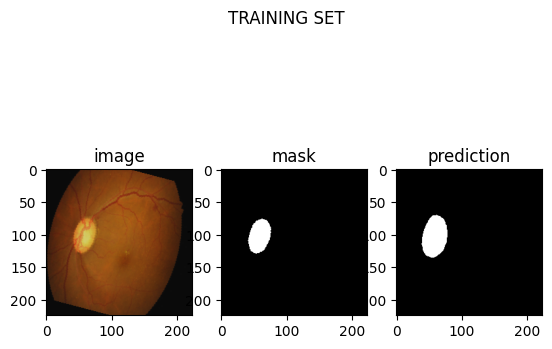

In [105]:
idx = 11
image, mask = trainset[idx]

model.eval()
with torch.no_grad():
    logits_mask = model(image.to(DEVICE).unsqueeze(0))
    mask_temp = mask.to(DEVICE).unsqueeze(0)
    loss1 = DiceLoss(mode="binary")(logits_mask, mask_temp)
    loss2 = nn.BCEWithLogitsLoss()(logits_mask, mask_temp.float())
    print(f"Dice loss {loss1:.4f} // BCE loss {loss2:.4f}")

print(f"Max logit: {logits_mask.max().item()}")
print(f"Min logit: {logits_mask.min().item()}")
print(f"Max prob: {torch.sigmoid(logits_mask).max().item()}")

pred_mask = torch.sigmoid(logits_mask) > 0.95
pred_mask = pred_mask.detach().cpu().squeeze(0)

plot_tensor_image_and_mask(image, mask, pred_mask, title="TRAINING SET")

Dice loss 0.8030 // BCE loss 0.2529


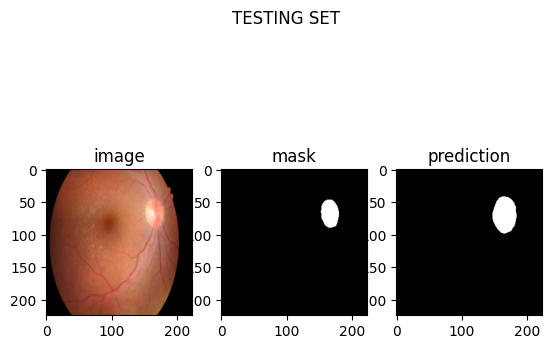

In [106]:
idx = 2
image, mask = testset[idx]

model.eval()
with torch.no_grad():
    logits_mask = model(image.to(DEVICE).unsqueeze(0))
    mask_temp = mask.to(DEVICE).unsqueeze(0)
    loss1 = DiceLoss(mode="binary")(logits_mask, mask_temp)
    loss2 = nn.BCEWithLogitsLoss()(logits_mask, mask_temp.float())
    print(f"Dice loss {loss1:.4f} // BCE loss {loss2:.4f}")

pred_mask = torch.sigmoid(logits_mask) > 0.95
pred_mask = pred_mask.detach().cpu().squeeze(0)

plot_tensor_image_and_mask(image, mask, pred_mask, title="TESTING SET")

Overall, the model performs fairly well. The training example is 72% accurate, while the testing example is 80% accurate (based on the Dice Loss). The lower accuracy of the training score can be attributed to the augmentations done on the dataset to improve robustness; the testing example was only resized.  

## HYPERPARAMTER TUNING
The following hyperparameter are explored:
* encoders, which can impact model accuracy and complexity: `["resnet34", "efficientnet-b0", "mobileone_s0"]` - resnet34 is the most complex, but is also proven in medical image segmentation
* learning rate, which can impact convergence time but may lead to instability: `[0.001, 0.0001]`

In the future, other hyperparameters to optimize can include number of training epochs, momentum, and exploring other encoders/architectures. 

In [110]:
encoders = ["resnet34", "efficientnet-b0", "mobileone_s0"]
ENCODER_WEIGHTS = "imagenet"
lrs = [0.001, 0.0001]
EPOCHS = 20

In [111]:
all_results = [] # save losses over all hyperparameter tuning
all_results_losses = {}

overall_best_valid_loss = np.inf
overall_corresponding_train_loss = None

for encoder in encoders:

    for lr in lrs:

        model = SegmentationModel(encoder=encoder, weights=ENCODER_WEIGHTS)
        model.to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        print(f">>> STARTING TRAINING LOOP FOR encoder={encoder}, lr={lr}")

        # track the best validation loss over the given number of epochs
        best_valid_loss = np.inf
        corresponding_train_loss = None

        all_train_loss = []
        all_valid_loss = []

        # TRAINING LOOP
        for i in range(EPOCHS):
            train_loss = train_seg_model(data_loader=trainloader, model=model, optimizer=optimizer)
            valid_loss = test_seg_model(data_loader=testloader, model=model)

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                corresponding_train_loss = train_loss

            all_train_loss.append(train_loss)
            all_valid_loss.append(valid_loss)
            print(f"    Epoch {i+1}/{EPOCHS}: train_loss {train_loss:.4f} // valid_loss {valid_loss:.4f}")
                
        # save results for all hyperparameter
        all_results.append([encoder, lr, best_valid_loss, corresponding_train_loss])
        all_results_losses[f"{encoder}_{lr}"] = {"train_loss": all_train_loss, "valid_loss": all_valid_loss}

        # check if best global model; if so, save it! 
        if best_valid_loss < overall_best_valid_loss:
            torch.save(model.state_dict(), "best_model.pt")
            print("saved model")
            overall_best_valid_loss = best_valid_loss
            overall_corresponding_train_loss = corresponding_train_loss

>>> STARTING TRAINING LOOP FOR encoder=resnet34, lr=0.001


100%|██████████| 2/2 [00:09<00:00,  4.67s/it]


    Epoch 1/20: train_loss 1.6548 // valid_loss 2.4315


100%|██████████| 2/2 [00:09<00:00,  4.95s/it]


    Epoch 2/20: train_loss 1.4159 // valid_loss 4.8243


...

    Epoch 18/20: train_loss 1.4770 // valid_loss 1.5984


100%|██████████| 2/2 [00:12<00:00,  6.40s/it]


    Epoch 19/20: train_loss 1.4631 // valid_loss 1.6371


100%|██████████| 2/2 [00:10<00:00,  5.08s/it]

    Epoch 20/20: train_loss 1.4564 // valid_loss 1.5153


RESULTS of hyperparameter tuning:
            encoder      LR  best_validation_loss  corresponding_training_loss
0         resnet34  0.0010              0.206081                     0.195935
1         resnet34  0.0001              1.301946                     1.302966
2  efficientnet-b0  0.0010              0.258537                     0.240628
3  efficientnet-b0  0.0001              1.260852                     1.189526
4     mobileone_s0  0.0010              0.368598                     0.358242
5     mobileone_s0  0.0001              1.515349                     1.456413


C:\Users\Michelle\AppData\Local\Temp\ipykernel_12268\1732485308.py:5: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=results_df, x="encoder", y="best_validation_loss", hue="LR", palette=sns.color_palette())


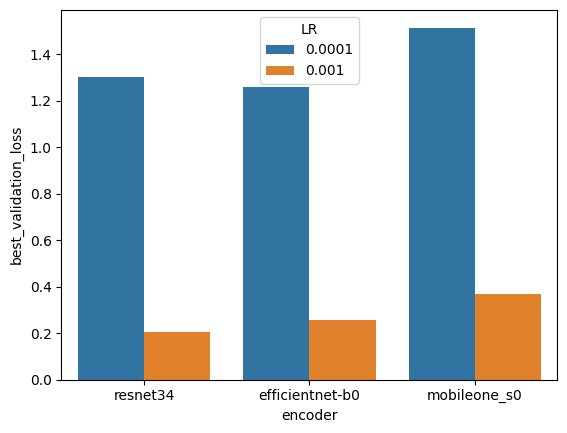

In [128]:
# look at overall results
results_df = pd.DataFrame(data=all_results, columns=["encoder", "LR", "best_validation_loss", "corresponding_training_loss"])
print("RESULTS of hyperparameter tuning:\n", results_df)

sns.barplot(data=results_df, x="encoder", y="best_validation_loss", hue="LR", palette=sns.color_palette())
plt.show()

Based on the results seen above, the following conclusions can be drawn:
* for 20 epochs, a learning rate of 0.001 resulted in lower training and validation loss. It shouldn't be concluded that a faster learning rate is necessarily better, as more epochs may be needed to have a similar response for the slower learning rate. However, for this specific use case, the faster learning rate did not result in instability, so is acceptable. 
* comparing the 3 encoders (at a same learning rate) shows that generally `resnet34` has lower losses than the other two encoders, although losses are fairly comparable. Considering that resnet34 is a more complex model, it may make sense to use `efficientnet-b0` if computational efficiency is a priority, even though `resnet34` tends to be more appropriate for medical imaging. 

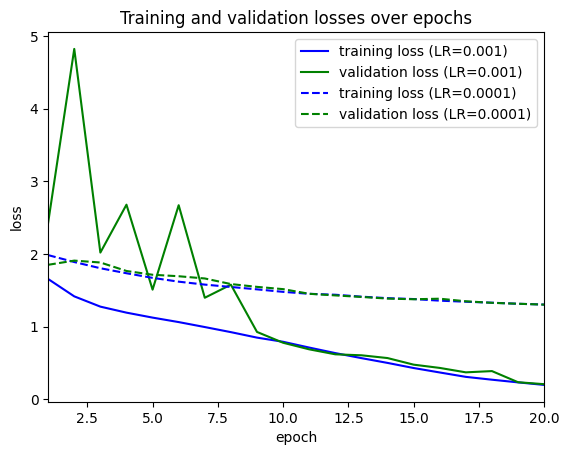

In [139]:
# plot graph of training vs validation loss for one model
plt.plot(range(1,21), all_results_losses["resnet34_0.001"]["train_loss"], color = 'blue') 
plt.plot(range(1,21), all_results_losses["resnet34_0.001"]["valid_loss"], color="green")
plt.plot(range(1,21), all_results_losses["resnet34_0.0001"]["train_loss"], '--', color = 'blue') 
plt.plot(range(1,21), all_results_losses["resnet34_0.0001"]["valid_loss"],"--", color="green")
plt.legend(["training loss (LR=0.001)", "validation loss (LR=0.001)", "training loss (LR=0.0001)", "validation loss (LR=0.0001)"])
plt.xlim([1,20])
plt.xlabel("epoch")
plt.ylabel("loss") 
plt.title("Training and validation losses over epochs")

plt.show();  

To further illustrate the effects of the hyperparameters and to explore how the number of epochs impacts loss, the training and validation losses were plotted for 2 learning rates using the same encoder; full line shows faster learning (0.001), while the dotted line shows slower learning (0.0001). For the slower learning, the training loss is higher than with the faster rate but the validation loss is lower than with the faster rate. Over 20 epochs, the loss decreases but much slower and starts to plateau. For such a learning rate, likely more epochs are necessary to get a low loss. For the faster learning, there is some initial instability in the validation loss in the first 10 epochs, with oscillation between high and low loss. Past 10 epochs, the validation loss and the training loss are very similar and both decreasing. The loss starts to plateau. 

### Inference with best saved model 
The best model was resnet34, with learning rate of 0.001. The predicted mask will be generated, both for a training and testing image. 

In [142]:
# load best saved model
model = SegmentationModel(encoder="resnet34", weights=ENCODER_WEIGHTS)
model.to(DEVICE)
model.load_state_dict(torch.load("best_model.pt"), strict=False)

<All keys matched successfully>

Dice loss 0.1383 // BCE loss 0.0115
Max logit: 9.043658256530762
Min logit: -6.299411296844482
Max prob: 0.9998818635940552


C:\Users\Michelle\AppData\Local\Temp\ipykernel_12268\1428040426.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


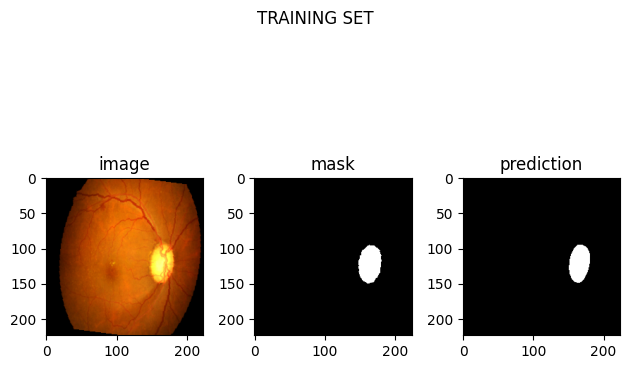

In [ ]:
idx = 11
image, mask = trainset[idx]

model.eval()
with torch.no_grad():
    logits_mask = model(image.to(DEVICE).unsqueeze(0))
    mask_temp = mask.to(DEVICE).unsqueeze(0)
    loss1 = DiceLoss(mode="binary")(logits_mask, mask_temp)
    loss2 = nn.BCEWithLogitsLoss()(logits_mask, mask_temp.float())
    print(f"Dice loss {loss1:.4f} // BCE loss {loss2:.4f}")

print(f"Max logit: {logits_mask.max().item()}")
print(f"Min logit: {logits_mask.min().item()}")
print(f"Max prob: {torch.sigmoid(logits_mask).max().item()}")

pred_mask = torch.sigmoid(logits_mask) > 0.95
pred_mask = pred_mask.detach().cpu().squeeze(0)

plot_tensor_image_and_mask(image, mask, pred_mask)

Dice loss 0.1702 // BCE loss 0.0096


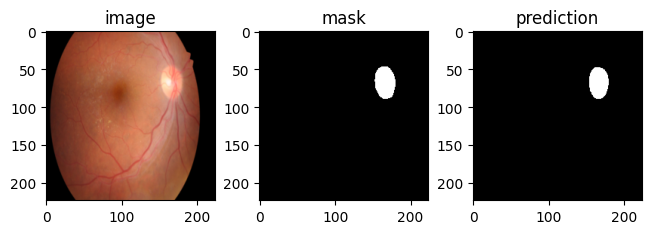

In [164]:
idx = 2
image, mask = testset[idx]

model.eval()
with torch.no_grad():
    logits_mask = model(image.to(DEVICE).unsqueeze(0))
    mask_temp = mask.to(DEVICE).unsqueeze(0)
    loss1 = DiceLoss(mode="binary")(logits_mask, mask_temp)
    loss2 = nn.BCEWithLogitsLoss()(logits_mask, mask_temp.float())
    print(f"Dice loss {loss1:.4f} // BCE loss {loss2:.4f}")

pred_mask = torch.sigmoid(logits_mask) > 0.95
pred_mask = pred_mask.detach().cpu().squeeze(0)

plot_tensor_image_and_mask(image, mask, pred_mask)

In [158]:
model.eval()

test_dice_losses = []
test_BCE_losses = []
for i in range(len(testset)):
    image, mask = testset[idx]

    with torch.no_grad():
        logits_mask = model(image.to(DEVICE).unsqueeze(0))
        mask_temp = mask.to(DEVICE).unsqueeze(0)
        test_dice_losses.append(DiceLoss(mode="binary")(logits_mask, mask_temp))
        test_BCE_losses.append(nn.BCEWithLogitsLoss()(logits_mask, mask_temp.float()))

test_dice_losses_avg = np.mean(test_dice_losses)
test_BCE_losses_avg = np.mean(test_BCE_losses)

print(f"Over testing samples, the avg Dice Loss was {test_dice_losses_avg:.4f} and the avg BCE Loss was {test_BCE_losses_avg:.4f}")

Over testing samples, the avg Dice Loss was 0.1702 and the avg BCE Loss was 0.0096


With an average Dice Loss of 0.1702 and average BCE Loss of 0.0096 over the testing/validation samples, it can be concluded that the model behaves well in segmenting the optic disc from the retinal images as there is about 83% overlap between the segmented object and the ground-truth mask. The BCE Loss is also low to the class imbalance, as there is much more background than there is optic disk. 